# Declaration of Originality

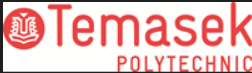

**TEMASEK POLYTECHNIC**
<br>**SCHOOL OF INFORMATICS & IT**
<br>**DIPLOMA IN INFORMATION TECHNOLOGY**
<br>**MACHINE LEARNING FOR DEVELOPERS (CAI2C08)**
<br>**AY2025/2026 OCTOBER SEMESTER**

**PROJECT PROGRAM CODES**
* Student Name (Matric Number)  : Jared Nathaniel John (2401776F)
* Tutorial Group                : PC05
* Tutor						    : Dr Kian Eng Ong
* Submission Date               : 11 February 2026



**Declaration of Originality**
* I am the originator of this work and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [18]:
## Import libraries
import pandas as pd
import sklearn
from sklearn import datasets
import matplotlib.pyplot as plt
import seaborn as sns


# 1. Business Understanding
<h2>Problem Statement</h2>
<h5>Cardiovascular diseases (CVDs) are the leading cause of death globally, taking an estimated 17.9 million lives each year. Early identification of individuals at high risk of heart disease is critical for medical professionals to implement preventative care, lifestyle changes, and medical interventions that can save lives and reduce the burden on healthcare systems.</h5>

## Project Objective
The primary goal of this project is to develop a predictive machine learning model that classifies whether an individual has a history of heart disease based on various health indicators. This is a classification task where the target variable is Heart_Disease (Yes/No).

# 2. Data Understanding

## 2.1 Load dataset

In [19]:
## Read *.csv file into pandas DataFrame FOR LOCALLY HOSTED
FILE_PATH = 'CVD_cleaned.csv'
df = pd.read_csv(FILE_PATH)
df

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Good,Within the past year,No,No,No,No,Yes,No,Yes,Male,60-64,183.0,154.22,46.11,No,0.0,12.0,12.0,12.0
1,Good,Within the past year,Yes,No,No,No,No,No,Yes,Female,65-69,165.0,108.86,39.94,Yes,3.0,30.0,8.0,8.0
2,Fair,Within the past year,No,No,No,No,Yes,No,No,Female,65-69,163.0,72.57,27.46,Yes,0.0,12.0,12.0,4.0
3,Fair,Within the past year,No,No,Yes,No,No,No,No,Male,65-69,178.0,113.40,35.87,Yes,4.0,2.0,3.0,4.0
4,Excellent,Within the past 2 years,Yes,No,No,No,No,No,No,Female,70-74,152.0,52.16,22.46,No,0.0,30.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102946,Good,Within the past year,Yes,No,No,No,No,No,No,Male,60-64,163.0,65.32,24.72,No,8.0,4.0,4.0,2.0
102947,Very Good,5 or more years ago,No,No,No,No,No,No,No,Male,40-44,163.0,65.77,24.89,No,0.0,0.0,0.0,0.0
102948,Good,Within the past 5 years,Yes,No,No,No,No,No,No,Male,55-59,168.0,58.97,20.98,No,0.0,16.0,12.0,0.0
102949,Very Good,Within the past year,Yes,No,No,No,No,No,No,Male,25-29,168.0,81.65,29.05,No,4.0,30.0,8.0,0.0


In [20]:
from google.colab import drive   ## FOR COLAB
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

In [ ]:
## Read *.csv file into pandas DataFrame  ~ FOR COLAB
FILE_PATH = '/content/drive/MyDrive/Colab Notebooks/CVD_cleaned.csv'
df = pd.read_csv(FILE_PATH)
df


,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150.0,32.66,14.54,Yes,0.0,30.0,16.0,12.0
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165.0,77.11,28.29,No,0.0,30.0,0.0,4.0
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163.0,88.45,33.47,No,4.0,12.0,3.0,16.0
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180.0,93.44,28.73,No,0.0,30.0,30.0,8.0
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191.0,88.45,24.37,Yes,0.0,8.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308849,Very Good,Within the past year,Yes,No,No,No,No,No,No,Male,25-29,168.0,81.65,29.05,No,4.0,30.0,8.0,0.0
308850,Fair,Within the past 5 years,Yes,No,No,No,No,Yes,No,Male,65-69,180.0,69.85,21.48,No,8.0,15.0,60.0,4.0
308851,Very Good,5 or more years ago,Yes,No,No,No,Yes,"Yes, but female told only during pregnancy",No,Female,30-34,157.0,61.23,24.69,Yes,4.0,40.0,8.0,4.0
308852,Very Good,Within the past year,Yes,No,No,No,No,No,No,Male,65-69,183.0,79.38,23.73,No,3.0,30.0,12.0,0.0


## 2.2 Summary Statistics

In [23]:
## Shape of the Dataframe
df.shape

(102951, 19)

In [24]:
## Understand the type of variable for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102951 entries, 0 to 102950
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   General_Health                102951 non-null  object 
 1   Checkup                       102951 non-null  object 
 2   Exercise                      102951 non-null  object 
 3   Heart_Disease                 102951 non-null  object 
 4   Skin_Cancer                   102951 non-null  object 
 5   Other_Cancer                  102951 non-null  object 
 6   Depression                    102951 non-null  object 
 7   Diabetes                      102951 non-null  object 
 8   Arthritis                     102951 non-null  object 
 9   Sex                           102951 non-null  object 
 10  Age_Category                  102951 non-null  object 
 11  Height_(cm)                   102951 non-null  float64
 12  Weight_(kg)                   102951 non-nul

In [25]:
# Check for any  missing values
df.isnull().sum()

General_Health                  0
Checkup                         0
Exercise                        0
Heart_Disease                   0
Skin_Cancer                     0
Other_Cancer                    0
Depression                      0
Diabetes                        0
Arthritis                       0
Sex                             0
Age_Category                    0
Height_(cm)                     0
Weight_(kg)                     0
BMI                             0
Smoking_History                 0
Alcohol_Consumption             0
Fruit_Consumption               0
Green_Vegetables_Consumption    0
FriedPotato_Consumption         0
dtype: int64

In [26]:
## Describe data distribution
df.describe(include = 'all')

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
count,102951,102951,102951,102951,102951,102951,102951,102951,102951,102951,102951,102951.000000,102951.000000,102951.000000,102951,102951.000000,102951.000000,102951.000000,102951.000000
unique,5,5,2,2,2,2,2,4,2,2,13,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN
top,Very Good,Within the past year,Yes,No,No,No,No,No,No,Female,65-69,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN
freq,36617,79796,79612,94708,92948,93063,82186,86460,69220,53355,11167,NaN,NaN,NaN,61091,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170.664287,83.712597,28.650392,NaN,5.086779,29.756583,15.096191,6.300551
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.647121,21.457605,6.546627,NaN,8.199063,24.854970,14.904777,8.515978
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,91.000000,26.760000,12.120000,NaN,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,163.000000,68.040000,24.210000,NaN,0.000000,12.000000,4.000000,2.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170.000000,81.650000,27.440000,NaN,1.000000,30.000000,12.000000,4.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,178.000000,95.250000,31.890000,NaN,6.000000,30.000000,20.000000,8.000000


## Summary of Data Understanding from Summary Statistics

The dataset comprises of **102951 entries** and **19 features**, with no missing values across any column. The features consist of **12 categorical** (object type) and **7 numerical** (float64 type) variables.

### Key observations include:

*   **Target Variable (`Heart_Disease`)**: It is a categorical variable with 'No' being the **dominating** class, indicating a significant **class imbalance** that will need to be addressed during model training.
*   **Categorical Features**: Variables like `General_Health`, `Checkup`, `Diabetes`, and `Age_Category` have multiple unique values beyond a simple binary choice. It was also noted that the `Diabetes` column, which is expected to be binary (Yes/No), currently has more than two unique values, suggesting the presence of abnormal values that will require **imputation or removal**. These categorical features will also require **one-hot encoding** to convert them into a numerical format suitable for machine learning models.
*   **Numerical Features**: Columns such as `Height_(cm)`, `Weight_(kg)`, and `BMI`, along with the consumption-related features (`Alcohol_Consumption`, `Fruit_Consumption`, etc.), show a wide range of values and potential **outliers**, as indicated by the spread between min/max and the quartile ranges. This suggests that  **outlier treatment** may be necessary for optimal model performance.




## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

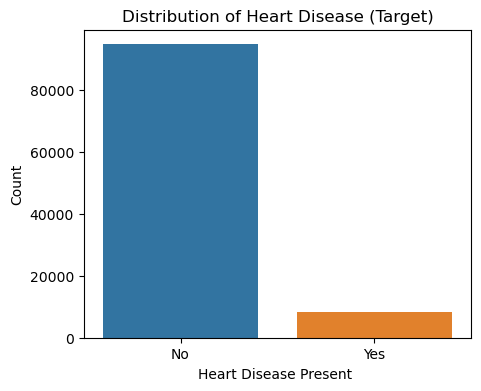

In [27]:
plt.figure(figsize=(5,4))
sns.countplot(x='Heart_Disease',hue = 'Heart_Disease', data=df)
plt.title('Distribution of Heart Disease (Target)')
plt.xlabel('Heart Disease Present ')
plt.ylabel('Count')
plt.show()

### Interpretation of Heart_Disease Distribution (UNSURE OF UNDER-OVER SAMPLING)

This plot clearly shows a significant class imbalance in the target variable, `Heart_Disease`. The number of instances where `Heart_Disease` is 'No' far outweighs those where it is 'Yes'. This imbalance is crucial to note as it can affect model training, potentially leading to models that are biased towards the majority class and perform poorly on the minority class. Strategies like oversampling, undersampling, or using appropriate evaluation metrics (e.g., precision, recall, F1-score) will be necessary during the modeling phase to handle this.

### 2.3.1.2 Understanding distribution of features

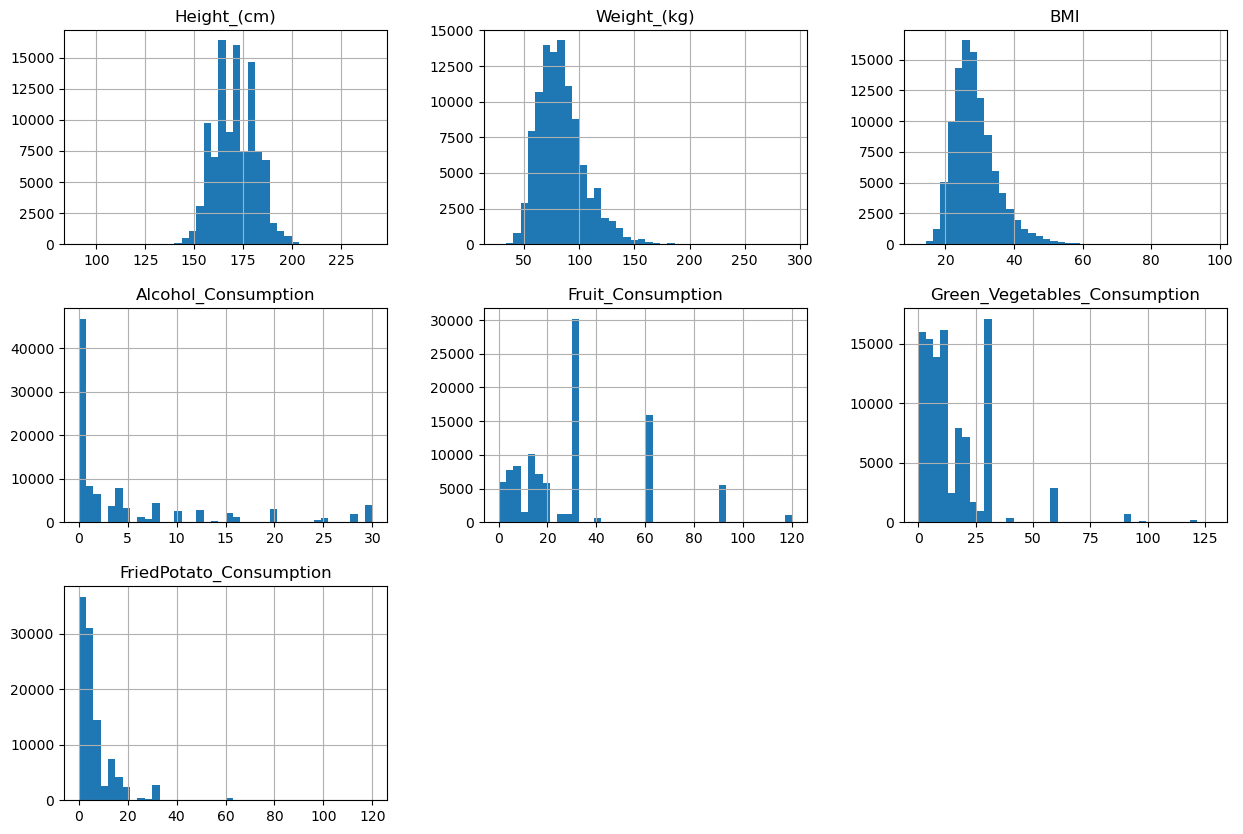

In [28]:
## Understanding distribution of features
df.hist(bins=40, figsize=(15, 10))
plt.show()

### Interpretation of Histograms for Numerical Features (REVIEW THIS)

The histograms illustrate the distribution of each numerical feature across the dataset. Most features exhibit a right-skewed distribution, indicating that lower values are more frequent, and there's a long tail towards higher values (e.g., `Alcohol_Consumption`, `Fruit_Consumption`, `Green_Vegetables_Consumption`, `FriedPotato_Consumption`). This skewness, along with the presence of outliers as observed in the boxplots, suggests that these features might benefit from transformations (e.g., log transformation) or robust scaling techniques during data preparation to achieve a more symmetrical distribution, which can improve the performance of some machine learning models. Features like `Height_(cm)`, `Weight_(kg)`, and `BMI` show more bell-shaped distributions, though `BMI` still has a notable right skew. The distributions provide valuable insights into the spread and central tendency of the data, reinforcing the need for careful feature engineering and scaling.

### 2.3.2 Understanding relationship between variables

### 2.3.2.0 Outlier Detection and Distribution by

*   List item
*   List item

Target (Boxplots)

<Figure size 600x400 with 0 Axes>

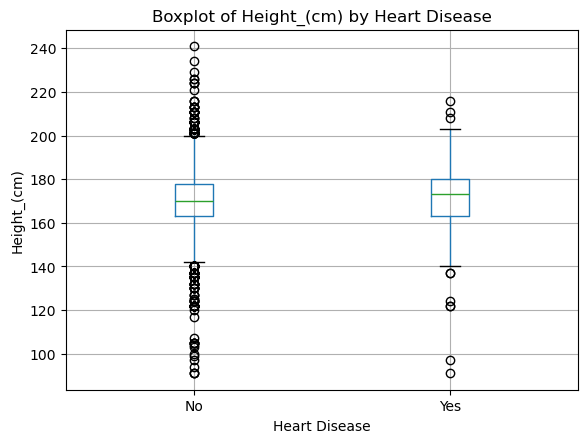

<Figure size 600x400 with 0 Axes>

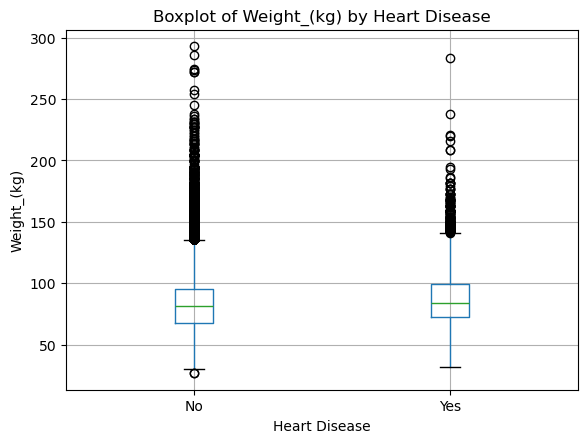

<Figure size 600x400 with 0 Axes>

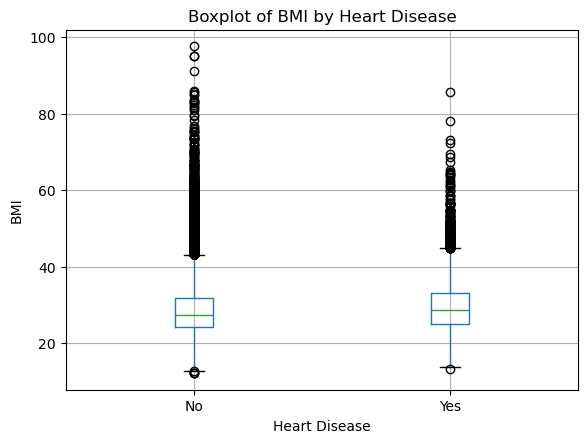

<Figure size 600x400 with 0 Axes>

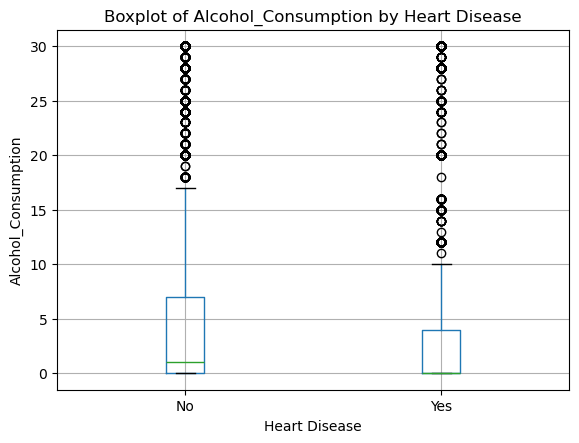

<Figure size 600x400 with 0 Axes>

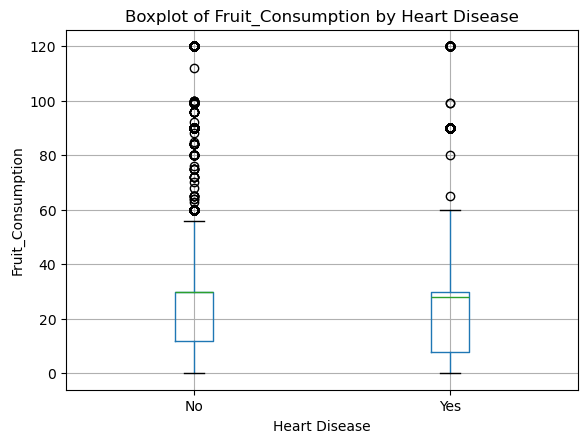

<Figure size 600x400 with 0 Axes>

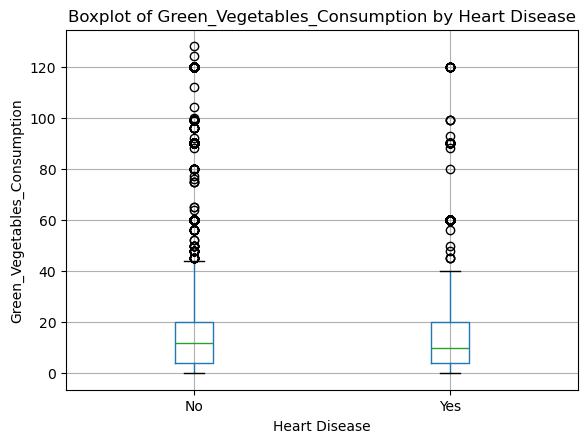

<Figure size 600x400 with 0 Axes>

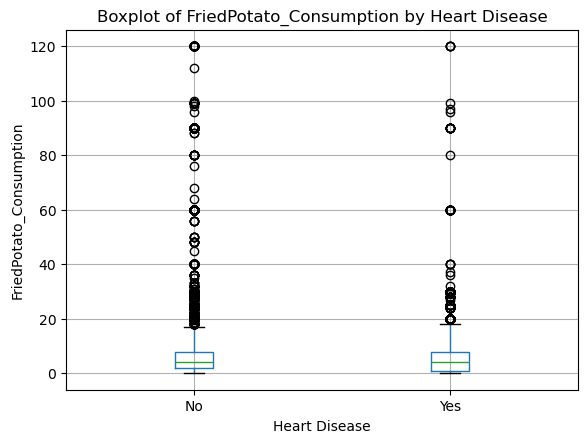

In [29]:
## Check for outliers
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    if col == 'Heart_Disease':
        continue

    plt.figure(figsize=(6, 4))
    df.boxplot(column=col, by='Heart_Disease', grid=True)
    plt.title(f'Boxplot of {col} by Heart Disease')
    plt.suptitle('')
    plt.xlabel('Heart Disease')
    plt.ylabel(col)
    plt.show()

### Interpretation of Boxplots for Numerical Features (UNSURE OF FEATURE SCALING)

The boxplots illustrate how numerical features are distributed among individuals with and without heart disease, while also highlighting potential outliers in the data. Several variables, including `Height_(cm)`, `Weight_(kg)`, `BMI`, `Alcohol_Consumption`, `Fruit_Consumption`, `Green_Vegetables_Consumption`, and `FriedPotato_Consumption`, show wide ranges with many values extending beyond the whiskers, indicating the presence of outliers. These extreme values may represent genuine lifestyle differences or possible data entry errors.

For some features, differences can be observed in the median and spread between individuals with and without heart disease, suggesting that these variables may be informative for predicting the target outcome. However, other features show largely overlapping distributions across both groups, indicating weaker separation. Overall, the presence of outliers across multiple numerical features suggests that preprocessing steps such as feature scaling or outlier handling may be required before training machine learning models to reduce the influence of extreme values on model performance.


### 2.3.2.1 Correlation Heatmap of Numerical Features

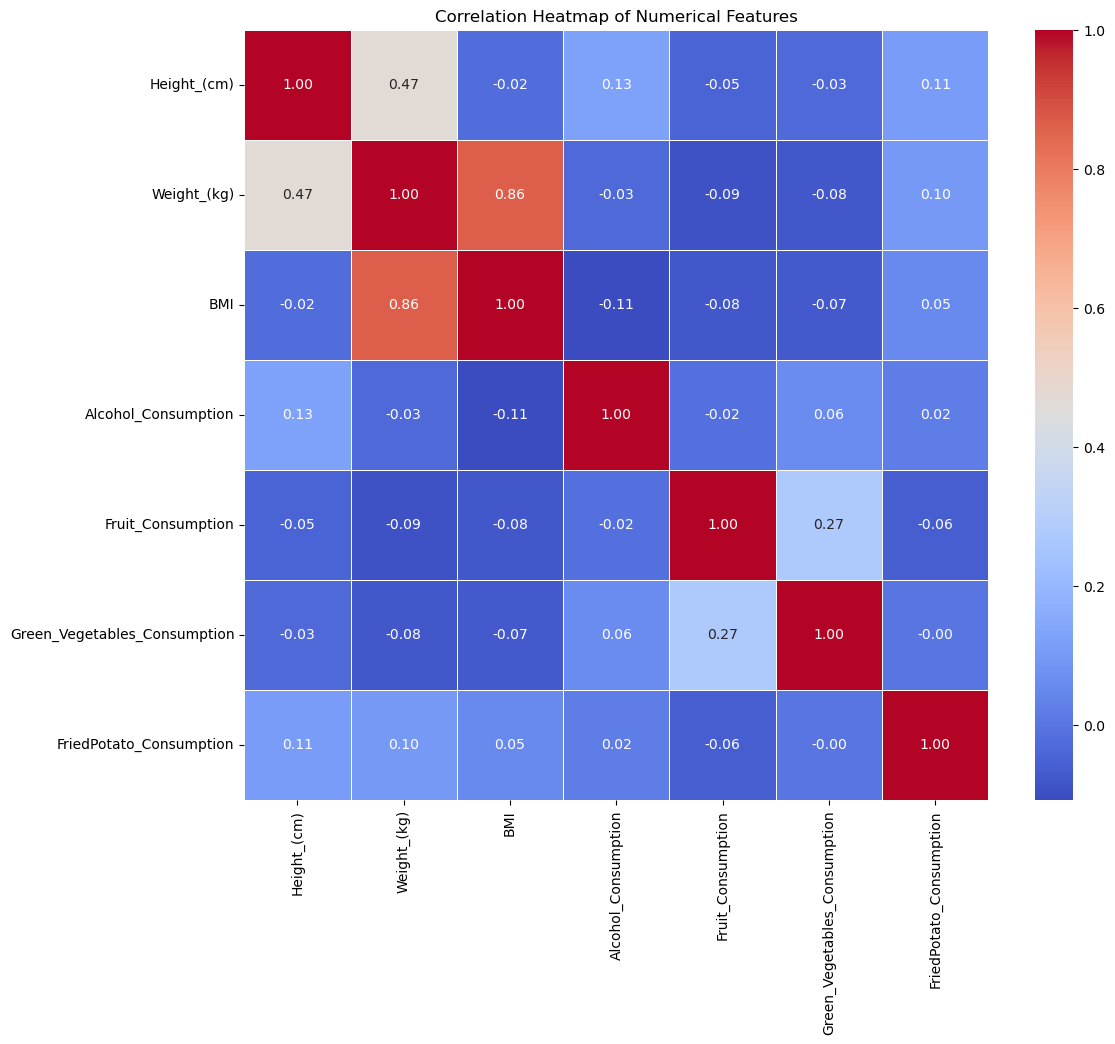

In [30]:
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### Interpretation of Correlation Heatmap of Numerical Features

The correlation heatmap provides insight into the linear relationships between the numerical features. A strong positive correlation is observed between `Weight_(kg)` and `BMI`, which is expected as BMI is calculated using weight. Similarly, `Height_(cm)` also shows a moderate positive correlation with `Weight_(kg)`. Most other numerical features exhibit weak to very weak correlations with each other, suggesting that multicollinearity might not be a major issue among these specific features, with the exception of the strong relationship between `Weight_(kg)` and `BMI`. Understanding these relationships helps in feature selection and engineering, as highly correlated features might carry redundant information.

### 2.3.2.2 Target vs. Key Categorical Feature: `Age_Category`

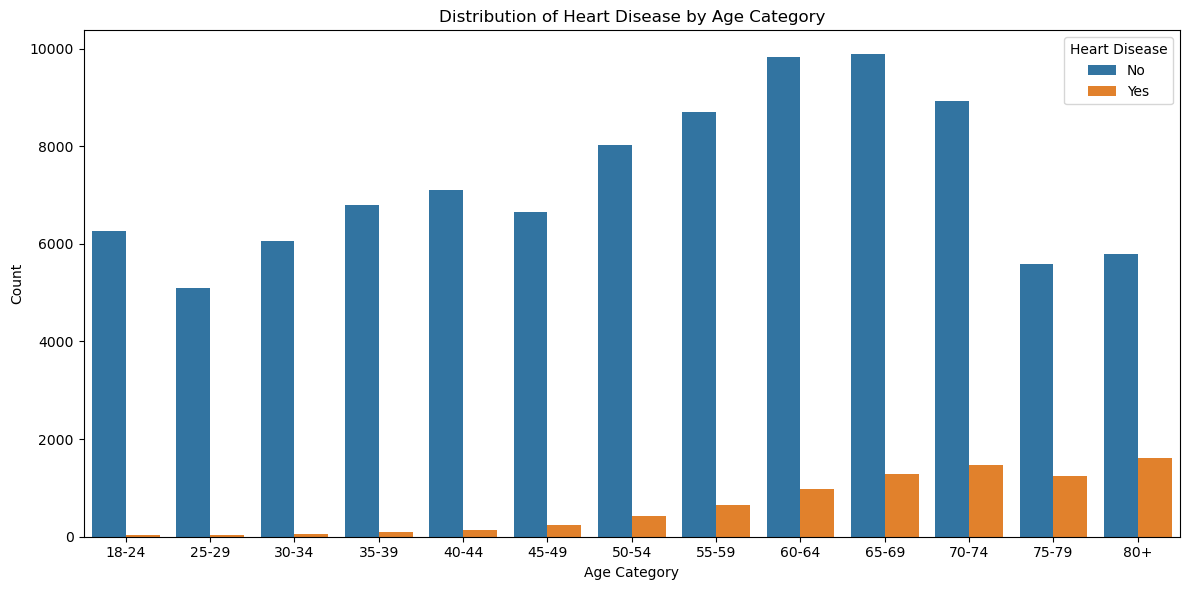

In [31]:
## Order the age groups
age_order = ['18-24','25-29','30-34','35-39','40-44', '45-49', '50-54',
             '55-59', '60-64', '65-69', '70-74','75-79','80+']

plt.figure(figsize=(12, 6)) ## Countplot
sns.countplot(
    x='Age_Category',
    hue='Heart_Disease',
    data=df,
    order=age_order ## Age group ordered
)

plt.title('Distribution of Heart Disease by Age Category')
plt.xlabel('Age Category')
plt.ylabel('Count')
plt.legend(title='Heart Disease')
plt.tight_layout()
plt.show()

### Interpretation of `Heart_Disease` vs. `Age_Category` Plot

This plot shows the count of individuals with and without heart disease across different age categories.

*   **Trends**: We can observe how the occurrence of heart disease (`Yes`) generally increases with age, which is an expected medical trend.
*   **Implications for Modelling**: The `Age_Category` feature appears to be a significant predictor due to its clear relationship with `Heart_Disease`. When encoding this categorical feature for machine learning models, an ordinal encoding might be suitable given the inherent order of age categories. This relationship should be carefully considered during feature engineering and model training.

# 3. Data Preparation

## 3.1 Data Cleaning

In [32]:
## Clean data

## 3.2 Train-Test Split

In [33]:
## Split data into train set and test set


# 4. Modelling

### 4.2 Train Model

In [ ]:
## Initialise and train model


# 5. Model Evaluation

In [ ]:
## Evaluate model


In [ ]:
## New data

## Predict


## Iterative model development


In [ ]:
## Further feature engineering / feature selection